In [146]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.optimize import curve_fit
from scipy import constants as const 
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator

# PW11 Elektrische Schwingungen

Moritz Bacher und Emilia Frei
16.12.2025

## 1. Experiment

In dem ersten Experiment sind verschiedene Größen einer freien Schwingung in einem Parallel-Schwingkreis zu bestimmen.  Ein solcher Schwingkreis besteht aus einer Spule mit Induktivität $L$, einem Kondensator mit Kapazität $C$ und einem Ohm'schen Widerstand $R$, welcher als Dämpfungswiderstand fungiert. Hier liegt keine Spannungsquelle im klassischen Sinne an, lediglich der Kondensator mit Anfangsladung $q_0$ führt zu einem Stromflus, die Spannung nimmt mit der Zeit ab. Zu diesem Widerstand trägt immer ein Widerstand $R_L$ der Spule bei. In Abhängigkeit von der Dämpfungskonstante $\delta$, welche wie folgt gegebn ist, fällt die normierte Kondensatorspannung schneller bzw. langsamer gegen 0. Hier wird einmal mit einem Aufbau mit minimaler Dämpfung, also keinem zusätlichen Dämpfungswiderstand, und einmal mit einem Aufbau mit stärkerer Dämpfung, also einem zusätzlichen Dämpfungswiderstand $R_D = 3 \Omega$, gearbeitet.

<br>

$$
\begin{equation}
\delta = \frac{R}{2L}
\end{equation}
$$

Wie gehabt ist die Eigenfrequenz $\omega_0$ gegeben durch:

$$
\begin{equation}
\omega_0 = \sqrt{\frac{1}{LC}} \tag{2}
\end{equation}
$$

Die Kreisfrequenz der gedämpften Schwingung ist in Abhängigkeit der Periodendauer $T$:
$$
\begin{equation}
\omega_d = \frac{2\pi}{T} \tag{3}
\end{equation}
$$

Die Amplituden der Spannung mit voranschreitender Zeit sind durch folgenden exponentiellen Zusammenhang zu bestimmen:
$$
\begin{equation}
A(t) = A_0 \cdot \exp^{-\delta t} \tag{4}
\end{equation}
$$ 

<br>

Mit diesen Größen lassen sich nun die im Experiment gesuchten Größen ermitteln.
$\delta$ lässt sich mittels folgendem linearen Zusammenhang durch einen linearen Fit bestimmen, wobei $\delta$ hier als Steigung agiert.

$$
\ln(\frac{A_i}{A_0}) = -\delta t_i
$$

$A_i$ beschreibt die Maxima, welche in Abhängigkeit von der Zeit gemessen werden. 
Mit dem durch Gleichung (3) bekanntem $\omega_d$, lässt sich nun durch

$$
\omega_0 = \sqrt{\omega_d^2 + \delta^2}
$$

die Eigenfrequenz $\omega_0$ berechnen. Mit Gleichung (1) wird für den Fall minimaler Dämpfung und der bekannten Induktivität $L$ der Widerstand der SPule $R_L$ berechnet, und mittels $\omega_0$ und  Gleichung (2) wird, erneut mithilfe von $L$, die Kapazität $C$ berechnet.

Die Kreisfrequenz der Schwingung beträgt 32057.07 Rad pro Sekunde.
Die Schwingung hat einen Dämpfungskoeffizienten von 562+/-33 1/s. 


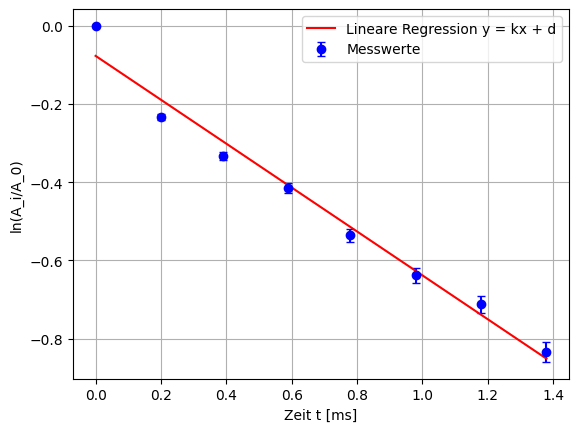

R^2 = 0.9793328741746071
Die Eigenfrequenz mit Berücksichtigung beträgt 32062.0+/-0.6 Rad pro Sekunde.
Der Kondensator besitzt die Kapazität C = (9.72790+/-0.00035)e-07 F und die Spule hat einen Widerstand von 1.12+/-0.07 Ohm.


In [147]:
# Experiment 1

# 1.1
T1 = ((200+200+180+200+200+200+200+180+200+200)/10)*(10**(-6))
#T1 = 2*(10**(-4)) #periodendauer in s
omegad1 = (2*math.pi)/T1 #eigenfrequenz

#T2 = #periodendauer
#omegad2 = (2/math.pi)/T2

print(f"Die Kreisfrequenz der Schwingung beträgt {omegad1:.2f} Rad pro Sekunde.")

# 1.2
A0_1 = 10.6 # in V
A_t_1 = np.array([10.6, 8.4, 7.6, 7, 6.2, 5.6, 5.2, 4.6])
y_1 = np.log(A_t_1/A0_1)
t_1 = np.array([0, 200*10**(-6), 390*10**(-6), 590*10**(-6), 780*10**(-6), 980*10**(-6), 1180*10**(-6), 1380*10**(-6)]) # die wievielten maxima wir eintragen, achtung auf die reihenfolge!! in s
t_1_plot = t_1*10**3

#A0_2 = 
#A_t_2 = np.array([])
#y_2 = math.log(A_t_2/A0_2)
#t_2 = np.array([]) # die wievielten maxima wir eintragen, achtung auf die reihenfolge!!

res1 = linregress(t_1, y_1)
delta_1 = ufloat(res1.slope, res1.stderr)*(-1) # weil steigung -delta ist, wert also positiv
y_reg = res1.slope*t_1 + res1.intercept 

#res2 = linregress(t_2, y_2)
#delta_2 = ufloat(res2.slope, res2.stderr)*(-1) # vorzeichen geändert

print(f"Die Schwingung hat einen Dämpfungskoeffizienten von {delta_1} 1/s. ")

y_err = np.array(-y_1*0.03)

# plot
plt.figure()
#plt.scatter(t_1_plot, y_1, marker="o", label="Messwerte", color='blue')
plt.errorbar(t_1_plot, y_1, yerr=y_err, fmt="o", capsize=3, label="Messwerte", color="blue")
plt.plot(t_1_plot, y_reg, label="Lineare Regression y = kx + d", color="red")
plt.xlabel("Zeit t [ms]")
plt.ylabel("ln(A_i/A_0)")
plt.grid(True)
plt.legend()
plt.show()

r2 = res1.rvalue**2
print(f"R^2 = {r2}")


# 1.3
omega0_1 = unp.sqrt((omegad1)**2 + (delta_1)**2)
#omega0_2 = np.sqrt((omegad2)**2 + (delta_2)**2)

print(f"Die Eigenfrequenz mit Berücksichtigung beträgt {omega0_1} Rad pro Sekunde.")

# 1.4
L = 1*10**(-3) # Widerstand der Spule in Henri
#L = (RL)/2*delta_1 # achtung ob das eh weniger dämpfung ist
RL = L*(2*delta_1)
C = 1/((omega0_1)**2*L)

print(f"Der Kondensator besitzt die Kapazität C = {C} F und die Spule hat einen Widerstand von {RL} Ohm.")

# 1.5
#RD = 0.6 # veränderbarer Widerstand in Ohm
#R = RD + RL
#delta_3 = R/(2*L)
#diff = delta_3 - omega0_2

#print(f"Beim Dämpfungswiderstand {R} Ohm, mit RD = {RD}, tritt der Dämpfungskoeffizient {delta_3} auf, was der Eigenfrequenz \u03C9\u2080 mit einer Differenz von diff sehr nahe kommt.")

wertefreieschwingung1 = np.array([omega0_1, delta_1])
#wertefreieschwingung2 = np.array([omega0_2, delta_2])

## 2. Experiment

Im zweiten Experiment geht es um erzwungene Schwingungen, also um Schwingkreise an denen eine Spannungsquelle anliegt. Gemessen wird die Resonanzkurve $U_{C0}$ rund um das Maximum $U_{max}$, welches bei der Kreisfrequenz $\omega_{max}$ anliegt. Für kleine Dämpfungen gilt $\omega_{max} \approx \omega_0$, welches bereits aus Experiment 1 bekannt ist.

$$
U_{C0} = U_0\frac{\omega_o^2}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\delta^2\omega^2}}
$$

Zusätlich wird nun auch die auftretende Phasenverschiebung $\varphi(\omega)$ bei $\omega_{max}$, $0.8\omega_{max}$ und $\omega_{max}$ gemessen. <br>
Für den Abstand $\Delta \omega$ der Kreisfrequenzen, bei welchem die Amplitude $U_{C0}$ auf $\frac{U_{max}}{\sqrt{2}}$ abfällt, gilt: 

$$
\Delta\omega = 2\delta
$$

So lässt sich dann sowohl die Eigenfrequenz $\omega_0$ 

$$
\omega_0 = \sqrt{\omega_{max}^2 + 2\delta^2}
$$

als auch die Güte $Q$

$$
Q \approx \frac{\omega_{max}}{\Delta\omega}
$$

bestimmen. Die Güte $Q$ beschreibt das Verhältnis zwischen der gespeicherten Energie und thermischem Energieverlust. Je größer die Güte $Q$ ist, desto schmaler ist die Resonanzkurve.

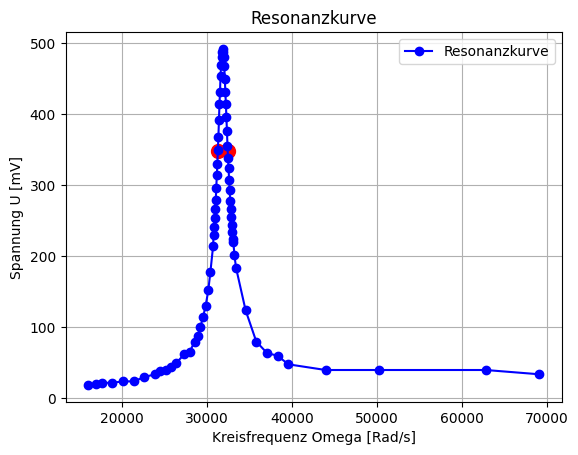

,Kreisfrequenz [Rad/s],Phasenverschiebung [Rad]
0,Omega_max,0.84
1,"0,8*Omega_max",0.00
2,"1,2*Omega_max",0.09


Die Eigenfrequenz dieser Schwingung liegt bei 5047.77 Rad pro Sekunde.
Die Dämfung beträgt hier 582.93.
Der Gütefaktor Q wurde als 4.27 bestimmt.


,Freie Schwingung,Erzwungene Schwingung
0,32062.0+/-0.6,5047.774173
1,562+/-33,582.934003


In [148]:
# 2. experiment 

# 2.1
UC0 = np.array([19, 20, 22, 22, 24, 24, 30, 34, 38, 40, 44, 50, 62, 66, 80, 88, 100, 114, 130, 152, 178, 214, 230, 242, 254, 266, 280, 296, 314, 330, 350, 368, 392, 414, 432, 454, 470, 480, 488, 492, 488, 480, 468, 450, 432, 414, 396, 376, 356, 338, 324, 308, 294, 278, 266, 256, 244, 234, 225, 220, 202, 184, 124, 80, 64, 60, 48, 40, 40, 40, 34]) # punktweise messung der spannung in mV
f = np.array([2550, 2700, 2800, 3000, 3200, 3400, 3600, 3800, 3900, 4000, 4100, 4200, 4350, 4450, 4550, 4600, 4650, 4700, 4750, 4800, 4840, 4890, 4900, 4910, 4920, 4930, 4940, 4950, 4960, 4970, 4980, 4990, 5000, 5010, 5020, 5030, 5040, 5050, 5060, 5070, 5080, 5090, 5100, 5110, 5120, 5130, 5140, 5150, 5160, 5170, 5180, 5190, 5200, 5210, 5220, 5230, 5240, 5250, 5260, 5270, 5290, 5320, 5500, 5700, 5900, 6100, 6300, 7000, 8000, 10000, 11000]) # frequenz in Hz
omega = 2*math.pi*f
#omega_max ist ca 4980 Hz

# 2.2
phi_omegamax = 0.84 #in rad
phi_0_8 = 0 
phi_1_2 = 0.09 #rad

phi = np.array([phi_omegamax, phi_0_8, phi_1_2])
name = np.array(["Omega_max", "0,8*Omega_max", "1,2*Omega_max"])

# eigenfrequenz, dämpfung, gütefaktor
Umax = 492 #mV
imax = np.argmax(UC0)
Uwurzel2 = (1/np.sqrt(2))*Umax
y1 = UC0[:imax+1]
omega1 = omega[:imax+1]
y2 = UC0[imax:]
omega2 = omega[imax:]
x1 = np.interp(Uwurzel2, y1, omega1)
x2 = np.interp(Uwurzel2, y2[::-1], omega2[::-1])
#omegamax = np.interp(Umax, UC0, omega)
omegamax = 4980 #gemessen
deltax = x2 - x1
delta_4 = deltax/2
Q = omegamax/deltax
omega0 = np.sqrt((omegamax)**2 + 2*((delta_4)**2))

werteerzwungeneschwingung = np.array([omega0, delta_4])

plt.figure()
plt.plot(omega, UC0, marker="o", label="Resonanzkurve", color='blue')
plt.scatter(x1, Uwurzel2, marker="o", color='red', s=100)
plt.scatter(x2, Uwurzel2, marker="o", color='red', s=100)
plt.xlabel("Kreisfrequenz Omega [Rad/s]")
plt.ylabel("Spannung U [mV]")
plt.title("Resonanzkurve")
plt.legend()
plt.grid(True)
plt.show()


tabelle = {
    "Kreisfrequenz [Rad/s]": name,
    "Phasenverschiebung [Rad]": phi
}
df = pd.DataFrame(tabelle)
display(df)

print(f"Die Eigenfrequenz dieser Schwingung liegt bei {omega0:.2f} Rad pro Sekunde.")
print(f"Die Dämfung beträgt hier {delta_4:.2f}.")
print(f"Der Gütefaktor Q wurde als {Q:.2f} bestimmt.")

vergleichstabelle = {
    "Freie Schwingung": wertefreieschwingung1,
    "Erzwungene Schwingung": werteerzwungeneschwingung
}
df_ = pd.DataFrame(vergleichstabelle)
display(df_)


## Diskussion

2. Experiment: 
Der Nulldurchgang der Spannung am Kondensator liegt zeitlich vor der Gesamtspannung, dementsprechend ist das Vorzeichen der Phasenverschiebung positiv.
